# SWAP-Constrained Unitary Compilation — Evaluation

Evaluates the model trained with `; swap_count=N` prompt conditioning against the
baseline model (no SWAP count in prompt).

**What we measure:**

1. **Compilation accuracy per requested SWAP count** — Does requesting fewer SWAPs hurt the model's ability to compile the target unitary?
2. **Exact-count compliance** — Does the model actually produce circuits with the requested number of SWAPs?
   - `exact_compliance_rate = fraction of circuits where actual_swap_count == requested`
   - `mean_swap_count` per requested count (should track the diagonal)
3. **Comparison to baseline** — Does the SWAP-conditioned model retain the same compilation quality when given a high/unconstrained count?

Note: the model is trained on exact counts (`swap_count=N`), not upper bounds.
To minimise SWAPs on hardware, request `swap_count=0`.

Run `swap_gate_analysis.ipynb` first to understand the status quo.

## Setup

In [1]:
import ast
import random
import sys
from pathlib import Path

import hydra
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from hydra.core.global_hydra import GlobalHydra
from IPython.display import display
from tqdm.auto import tqdm

sys.path.append("/home/a-ldungl/projects/qcircuit-generation")

from notebooks.shared.bootstrap import setup_notebook_paths
PROJECT_ROOT = setup_notebook_paths()

from notebooks.shared.evaluation_artifacts import make_artifact_dir, save_dataframe, save_figure, save_json, save_pickle
from my_genQC.inference.sampling import generate_compilation_tensors, decode_tensors_to_backend
from my_genQC.inference.evaluation_helper import get_unitaries
from my_genQC.inference.eval_metrics import UnitaryInfidelityNorm, UnitaryFrobeniusNorm
from my_genQC.pipeline.diffusion_pipeline import DiffusionPipeline
from my_genQC.platform.simulation import CircuitBackendType, Simulator
from my_genQC.platform.tokenizer.circuits_tokenizer import CircuitTokenizer
from my_genQC.utils.misc_utils import infer_torch_device
from quantum_diffusion.data.dataset import DatasetLoader

In [2]:
# -- Configuration (edit as needed) -------------------------------------------

# Eval dataset — same one used for baseline evaluation
EVAL_DATASET_PATH = "./artifacts/datasets/unitary-baseline-reproduction/eval/qiskit"

# Fine-tuned model (init from baseline, trained on swap-constrained dataset)
FINETUNED_MODEL_DIR = "./artifacts/models/unitary-swap-finetuned/unitary_swap_finetuned"

# Baseline model (no SWAP count conditioning) — results loaded from CSV, not re-run
BASELINE_MODEL_DIR = "./artifacts/models/unitary-baseline-reproduction/paper_unitary"

# From-scratch model — results loaded from CSV, not re-run
SWAP_MODEL_DIR = "./artifacts/models/unitary-swap-constrained/unitary_swap_constrained"

# Directory where from-scratch + baseline results were previously saved
FROM_SCRATCH_ARTIFACT_DIR_STR = "./artifacts/evaluations/unitary-swap-constrained/swap_count_evaluation"

# Exact SWAP counts to request at inference (model was trained on exact counts)
SWAP_COUNTS = [0, 1, 2, 3]
# High count used as the 'unconstrained' reference for the constrained models
UNCONSTRAINED_COUNT = 6

# Evaluation settings
NUM_EVAL_UNITARIES = 128
SAMPLES_PER_UNITARY = 64
GUIDANCE_SCALE = 7.5
SAMPLE_STEPS = 20
MAX_GATES = 12
AUTO_BATCH_SIZE = 128
EXACT_DISTANCE_TOL = 1e-8
SEED = 42

# New artifacts go here (finetuned run only)
ARTIFACT_SUBDIR = "unitary-swap-finetuned"
RUN_NAME = "swap_count_evaluation"

device = str(infer_torch_device())
print(f"Device: {device}")

ARTIFACT_DIR = make_artifact_dir(PROJECT_ROOT, ARTIFACT_SUBDIR, RUN_NAME)
FROM_SCRATCH_ARTIFACT_DIR = Path(PROJECT_ROOT) / FROM_SCRATCH_ARTIFACT_DIR_STR
print(f"Finetuned artifacts:    {ARTIFACT_DIR}")
print(f"From-scratch artifacts: {FROM_SCRATCH_ARTIFACT_DIR}")

[INFO]: Cuda device has a capability of 8.0 (>= 8), allowing tf32 matmul.
Device: cuda
Finetuned artifacts:    /home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/unitary-swap-finetuned/swap_count_evaluation
From-scratch artifacts: /home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/unitary-swap-constrained/swap_count_evaluation


## Load models and dataset

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_pipeline(model_dir):
    path = Path(model_dir).expanduser().resolve()
    pipeline = DiffusionPipeline.from_config_file(config_path=str(path) + "/", device=device)
    pipeline.guidance_sample_mode = "rescaled"
    pipeline.scheduler.set_timesteps(SAMPLE_STEPS)
    return pipeline


set_seed(SEED)

# Eval dataset
GlobalHydra.instance().clear()
with hydra.initialize(version_base=None, config_path="../../../conf"):
    cfg = hydra.compose(config_name="config.yaml", overrides=["evaluation=paper_srv"])
eval_cfg = cfg["evaluation"]
eval_cfg.dataset = str(Path(EVAL_DATASET_PATH).expanduser().resolve())
eval_cfg.model_dir = str(Path(FINETUNED_MODEL_DIR).expanduser().resolve())
eval_cfg.save_output = False
eval_cfg.wandb.enable = False

loader = DatasetLoader(eval_cfg, device=device)
eval_dataset = loader.load_dataset(eval_cfg.dataset, load_embedder=False)
gate_pool = eval_dataset.gate_pool
print(f"Eval dataset: {len(eval_dataset.y):,} circuits, gate_pool: {gate_pool}")

# Shared tokenizer and simulator
vocabulary = {gate: idx for idx, gate in enumerate(gate_pool)}
tokenizer = CircuitTokenizer(vocabulary)
simulator = Simulator(CircuitBackendType.QISKIT)

# Load finetuned model only — from-scratch and baseline results come from saved CSVs
print("\nLoading finetuned model...")
finetuned_pipeline = load_pipeline(FINETUNED_MODEL_DIR)

2026-05-25 16:54:26 - quantum_diffusion.data.dataset - INFO - Detected preprocessed dataset. Loading directly...


[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit/dataset/ds_x.safetensors` onto device: cuda.


[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit/dataset/ds_y.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit/dataset/ds_U.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit/dataset/ds_z.safetensors` onto device: cuda.
[INFO]: Instantiated config_dataset from given config on cuda.
2026-05-25 16:54:26 - quantum_diffusion.data.dataset - INFO - Dataset loaded from /home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit


Eval dataset: 2,800 circuits, gate_pool: ['h', 'cx', 'z', 'x', 'ccx', 'swap']
[WARNING]: The value 0 is reserved for background tokens, i.e. qubit time position which are not effected by gates.
[WARNING]: Automatically incrementing all vocabulary values by one ...

Loading finetuned model...


[INFO]: `genQC.models.unet_qc.QC_Compilation_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `artifacts/models/unitary-swap-finetuned/unitary_swap_finetuned/model.pt` onto device: cuda.
[INFO]: `genQC.models.unet_qc.QC_Compilation_UNet`. Freeze model: True


[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder` instantiated from given `config` on cuda.
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Found no key `save_type` in `config`. No state dict loaded.
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Freeze model: True
[INFO]: `genQC.models.unet_qc.QC_Compilation_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `artifacts/models/unitary-swap-finetuned/unitary_swap_finetuned/embedder.pt` onto device: cuda.
[INFO]: `genQC.models.unet_qc.QC_Compilation_UNet`. Freeze model: True


In [4]:
# Select the same target unitaries for all experiments
rng = random.Random(SEED)
eval_indices = rng.sample(range(len(eval_dataset.y)), k=min(NUM_EVAL_UNITARIES, len(eval_dataset.y)))
print(f"Selected {len(eval_indices)} target unitaries")

Selected 128 target unitaries


## Evaluation loop

In [5]:
def make_prompt(gate_pool, swap_count=None):
    """Build the text prompt, optionally appending an exact SWAP count."""
    base = f"Compile using: {[str(g) for g in gate_pool]}"
    if swap_count is not None:
        return f"{base}; swap_count={swap_count}"
    return base


def evaluate(pipeline, model_label: str, swap_count):  # swap_count: int or None
    """Run evaluation for one (model, requested SWAP count) combination."""
    prompt = make_prompt(gate_pool, swap_count)
    rows = []

    for idx in tqdm(eval_indices, desc=f"{model_label} | swap_count={swap_count}", leave=False):
        target_u_split = eval_dataset.U[idx].cpu()

        # Recompute target unitary at float64 from stored circuit to avoid float32 quantization
        # errors. float32 cannot exactly represent 1/sqrt(2), causing ~2.14e-4 infidelity for
        # H-gate circuits which falsely fail the 1e-8 exact threshold.
        try:
            ref_instructions = tokenizer.decode(eval_dataset.x[idx])
            ref_qc = simulator.backend.genqc_to_backend(ref_instructions, place_barriers=False)
            target_u = simulator.backend.get_unitary(ref_qc)
        except Exception:
            target_u = target_u_split[0].numpy() + 1j * target_u_split[1].numpy()

        tensors_out = generate_compilation_tensors(
            pipeline=pipeline,
            prompt=[prompt],
            U=target_u_split.float().unsqueeze(0).to(device),
            samples=SAMPLES_PER_UNITARY,
            system_size=eval_dataset.x.shape[1],
            num_of_qubits=getattr(eval_dataset.params_config, "num_of_qubits", eval_dataset.x.shape[1]),
            max_gates=MAX_GATES,
            g=GUIDANCE_SCALE,
            auto_batch_size=AUTO_BATCH_SIZE,
            enable_params=False,
            no_bar=True,
        )

        decoded_circuits, _ = decode_tensors_to_backend(
            simulator=simulator,
            tokenizer=tokenizer,
            tensors=tensors_out,
            params=None,
            silent=True,
            n_jobs=1,
            filter_errs=False,
        )

        for qc in decoded_circuits:
            if qc is None:
                rows.append({"dataset_idx": idx, "actual_swap": None, "exact": False,
                             "valid": False, "count_matched": None, "infidelity": None})
                continue
            actual_swap = sum(1 for inst in qc.data if inst.operation.name == "swap")
            gen_u = simulator.backend.get_unitary(qc)
            # Compare at complex128 (float64) — casting to complex64 reintroduces float32
            # quantization error (~1.19e-7) which would falsely exceed the 1e-8 threshold.
            infidelity = float(UnitaryInfidelityNorm.distance(
                torch.as_tensor(gen_u).to(torch.complex128),
                torch.as_tensor(target_u).to(torch.complex128),
            ).item())
            exact = infidelity <= EXACT_DISTANCE_TOL
            count_matched = (actual_swap == swap_count) if swap_count is not None else None
            rows.append({
                "dataset_idx": idx,
                "actual_swap": actual_swap,
                "exact": exact,
                "valid": True,
                "count_matched": count_matched,
                "infidelity": infidelity,
            })

    df = pd.DataFrame(rows)
    valid = df[df["valid"]]
    exact_found_rate = valid.groupby("dataset_idx")["exact"].any().mean() if len(valid) else float("nan")
    exact_compliance = float(df["count_matched"].dropna().mean()) if df["count_matched"].notna().any() else float("nan")
    mean_abs_err = float((df["actual_swap"].dropna() - swap_count).abs().mean()) if swap_count is not None and len(df["actual_swap"].dropna()) else float("nan")
    wrong = valid[~valid["exact"]]

    summary = {
        "model": model_label,
        "requested_swap_count": swap_count,
        "prompt": prompt,
        "exact_found_rate": exact_found_rate,
        "mean_exact_count": float(valid.groupby("dataset_idx")["exact"].sum().mean()) if len(valid) else float("nan"),
        "valid_decode_rate": float(df["valid"].mean()),
        "mean_actual_swap": float(valid["actual_swap"].mean()) if len(valid) else float("nan"),
        "median_actual_swap": float(valid["actual_swap"].median()) if len(valid) else float("nan"),
        "zero_swap_frac": float((valid["actual_swap"] == 0).mean()) if len(valid) else float("nan"),
        "exact_compliance_rate": exact_compliance,
        "mean_abs_swap_error": mean_abs_err,
        "mean_infidelity_wrong": float(wrong["infidelity"].mean()) if len(wrong) else float("nan"),
        "median_infidelity_wrong": float(wrong["infidelity"].median()) if len(wrong) else float("nan"),
        "mean_infidelity_all": float(valid["infidelity"].mean()) if len(valid) else float("nan"),
    }
    print(
        f"{model_label} | requested={swap_count}: "
        f"exact_found={exact_found_rate:.3f}, "
        f"mean_actual_swap={summary['mean_actual_swap']:.2f}, "
        f"compliance={exact_compliance:.3f}, "
        f"mean_infidelity_wrong={summary['mean_infidelity_wrong']:.4f}"
    )
    return df, summary

In [6]:
def compute_summary_from_df(df, model_label, swap_count):
    """Recompute summary statistics from a per-circuit DataFrame."""
    valid = df[df["valid"]]
    exact_found_rate = valid.groupby("dataset_idx")["exact"].any().mean() if len(valid) else float("nan")
    exact_compliance = float(df["count_matched"].dropna().mean()) if df["count_matched"].notna().any() else float("nan")
    mean_abs_err = float((df["actual_swap"].dropna() - swap_count).abs().mean()) if swap_count is not None and len(df["actual_swap"].dropna()) else float("nan")
    wrong = valid[~valid["exact"]]
    prompt = make_prompt(gate_pool, swap_count)
    return {
        "model": model_label,
        "requested_swap_count": swap_count,
        "prompt": prompt,
        "exact_found_rate": exact_found_rate,
        "mean_exact_count": float(valid.groupby("dataset_idx")["exact"].sum().mean()) if len(valid) else float("nan"),
        "valid_decode_rate": float(df["valid"].mean()),
        "mean_actual_swap": float(valid["actual_swap"].mean()) if len(valid) else float("nan"),
        "median_actual_swap": float(valid["actual_swap"].median()) if len(valid) else float("nan"),
        "zero_swap_frac": float((valid["actual_swap"] == 0).mean()) if len(valid) else float("nan"),
        "exact_compliance_rate": exact_compliance,
        "mean_abs_swap_error": mean_abs_err,
        "mean_infidelity_wrong": float(wrong["infidelity"].mean()) if len(wrong) else float("nan"),
        "median_infidelity_wrong": float(wrong["infidelity"].median()) if len(wrong) else float("nan"),
        "mean_infidelity_all": float(valid["infidelity"].mean()) if len(valid) else float("nan"),
    }


def load_from_csv(model_label, swap_count, artifact_dir):
    """Load previously saved per-circuit CSV and recompute summary."""
    label = f"{model_label}_budget{swap_count}"
    csv_path = Path(artifact_dir) / f"{label}_per_circuit.csv"
    df = pd.read_csv(csv_path)
    summary = compute_summary_from_df(df, model_label, swap_count)
    print(f"Loaded {model_label} | requested={swap_count}: exact_found={summary['exact_found_rate']:.3f}")
    return df, summary


set_seed(SEED)

results = {}  # (model_label, requested_swap_count) -> {"df": ..., "summary": ...}

# --- Load from-scratch results from CSVs (not re-run) ---
print("Loading from-scratch (swap_constrained) results from CSV...")
for count in SWAP_COUNTS + [UNCONSTRAINED_COUNT]:
    df, summary = load_from_csv("swap_constrained", count, FROM_SCRATCH_ARTIFACT_DIR)
    results[("swap_constrained", count)] = {"df": df, "summary": summary}

# --- Load baseline results from CSV (not re-run) ---
print("\nLoading baseline results from CSV...")
df_base, summary_base = load_from_csv("baseline", None, FROM_SCRATCH_ARTIFACT_DIR)
results[("baseline", None)] = {"df": df_base, "summary": summary_base}

# --- Finetuned model: run fresh inference ---
print("\nRunning finetuned model evaluation...")
for count in SWAP_COUNTS + [UNCONSTRAINED_COUNT]:
    df, summary = evaluate(finetuned_pipeline, "swap_finetuned", count)
    results[("swap_finetuned", count)] = {"df": df, "summary": summary}

print("\nDone.")

Loading from-scratch (swap_constrained) results from CSV...
Loaded swap_constrained | requested=0: exact_found=0.648
Loaded swap_constrained | requested=1: exact_found=0.633


Loaded swap_constrained | requested=2: exact_found=0.672
Loaded swap_constrained | requested=3: exact_found=0.469
Loaded swap_constrained | requested=6: exact_found=0.477

Loading baseline results from CSV...
Loaded baseline | requested=None: exact_found=0.961

Running finetuned model evaluation...


swap_finetuned | swap_count=0:   0%|          | 0/128 [00:00<?, ?it/s]

swap_finetuned | requested=0: exact_found=0.898, mean_actual_swap=0.03, compliance=0.970, mean_infidelity_wrong=0.8452


swap_finetuned | swap_count=1:   0%|          | 0/128 [00:00<?, ?it/s]

...

swap_finetuned | requested=2: exact_found=0.914, mean_actual_swap=2.15, compliance=0.824, mean_infidelity_wrong=0.8486


swap_finetuned | swap_count=3:   0%|          | 0/128 [00:00<?, ?it/s]

swap_finetuned | requested=3: exact_found=0.891, mean_actual_swap=3.16, compliance=0.763, mean_infidelity_wrong=0.8478


swap_finetuned | swap_count=6:   0%|          | 0/128 [00:00<?, ?it/s]

swap_finetuned | requested=6: exact_found=0.750, mean_actual_swap=5.89, compliance=0.874, mean_infidelity_wrong=0.8676

Done.


## Results

In [7]:
summaries = [v["summary"] for v in results.values()]
summary_df = pd.DataFrame(summaries)
display(summary_df.round(4))

save_dataframe(summary_df, ARTIFACT_DIR / "swap_budget_summary.csv", index=False)

,model,requested_swap_count,prompt,exact_found_rate,mean_exact_count,valid_decode_rate,mean_actual_swap,median_actual_swap,zero_swap_frac,exact_compliance_rate,mean_abs_swap_error,mean_infidelity_wrong,median_infidelity_wrong,mean_infidelity_all
0,swap_constrained,0.0,"Compile using: ['h', 'cx', 'z', 'x', 'ccx', 's...",0.6484,21.2422,0.9954,0.0000,0.0,1.0000,1.0000,0.0000,0.8480,0.9375,0.5653
1,swap_constrained,1.0,"Compile using: ['h', 'cx', 'z', 'x', 'ccx', 's...",0.6328,17.5469,0.9962,0.9996,1.0,0.0004,0.9996,0.0004,0.8461,0.9375,0.6132
2,swap_constrained,2.0,"Compile using: ['h', 'cx', 'z', 'x', 'ccx', 's...",0.6719,23.9453,0.9955,1.9996,2.0,0.0000,0.9994,0.0006,0.8572,0.9375,0.5351
3,swap_constrained,3.0,"Compile using: ['h', 'cx', 'z', 'x', 'ccx', 's...",0.4688,13.2734,0.9960,2.9995,3.0,0.0000,0.9995,0.0005,0.8649,0.9375,0.6848
4,swap_constrained,6.0,"Compile using: ['h', 'cx', 'z', 'x', 'ccx', 's...",0.4766,6.8984,0.9961,5.9980,6.0,0.0000,0.9980,0.0020,0.9115,0.9375,0.8129
5,baseline,NaN,"Compile using: ['h', 'cx', 'z', 'x', 'ccx', 's...",0.9609,48.0547,0.9982,0.9880,1.0,0.3680,NaN,NaN,0.8049,0.7500,0.1994
6,swap_finetuned,0.0,"Compile using: ['h', 'cx', 'z', 'x', 'ccx', 's...",0.8984,34.7891,0.9971,0.0304,0.0,0.9696,0.9696,0.0304,0.8452,0.8594,0.3844
7,swap_finetuned,1.0,"Compile using: ['h', 'cx', 'z', 'x', 'ccx', 's...",0.9219,36.5469,0.9950,1.1499,1.0,0.0096,0.8309,0.1691,0.8471,0.8594,0.3609
8,swap_finetuned,2.0,"Compile using: ['h', 'cx', 'z', 'x', 'ccx', 's...",0.9141,41.2734,0.9967,2.1456,2.0,0.0000,0.8238,0.1762,0.8486,0.9375,0.2995
9,swap_finetuned,3.0,"Compile using: ['h', 'cx', 'z', 'x', 'ccx', 's...",0.8906,31.1953,0.9899,3.1602,3.0,0.0000,0.7629,0.2371,0.8478,0.8594,0.4303


PosixPath('/home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/unitary-swap-finetuned/swap_count_evaluation/swap_budget_summary.csv')

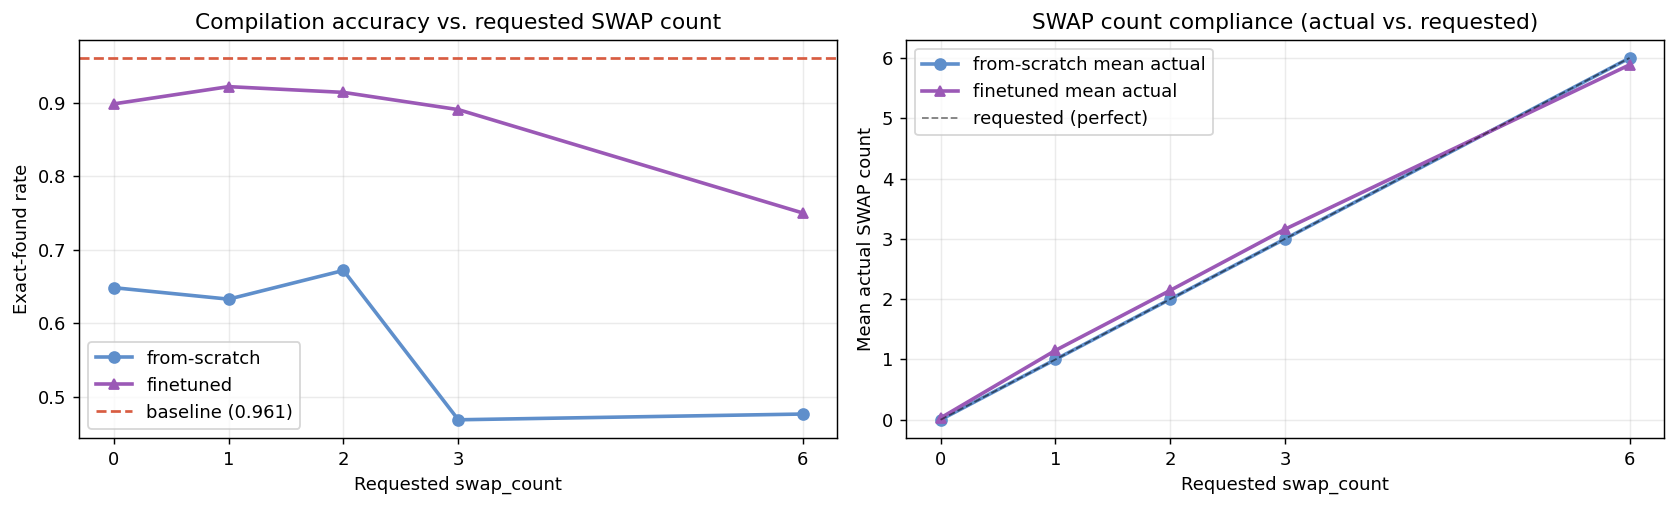

In [8]:
# Plot 1: Compilation accuracy vs. requested SWAP count — all three models
def get_model_series(model_label):
    rows = [v["summary"] for (m, b), v in results.items() if m == model_label and b is not None]
    rows.sort(key=lambda r: r["requested_swap_count"])
    return (
        [r["requested_swap_count"] for r in rows],
        [r["exact_found_rate"] for r in rows],
        [r["mean_actual_swap"] for r in rows],
    )

sc_counts, sc_exact, sc_actuals = get_model_series("swap_constrained")
ft_counts, ft_exact, ft_actuals = get_model_series("swap_finetuned")
baseline_exact = results[("baseline", None)]["summary"]["exact_found_rate"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=130)

# Accuracy
axes[0].plot(sc_counts, sc_exact, marker="o", color="#5f8fcb", linewidth=2, label="from-scratch")
axes[0].plot(ft_counts, ft_exact, marker="^", color="#9b59b6", linewidth=2, label="finetuned")
axes[0].axhline(baseline_exact, color="#d85c41", linestyle="--", linewidth=1.5, label=f"baseline ({baseline_exact:.3f})")
axes[0].set_xlabel("Requested swap_count")
axes[0].set_ylabel("Exact-found rate")
axes[0].set_title("Compilation accuracy vs. requested SWAP count")
axes[0].legend()
axes[0].grid(True, alpha=0.25)
axes[0].set_xticks(sc_counts)

# SWAP compliance (mean actual vs. requested)
axes[1].plot(sc_counts, sc_actuals, marker="o", color="#5f8fcb", linewidth=2, label="from-scratch mean actual")
axes[1].plot(ft_counts, ft_actuals, marker="^", color="#9b59b6", linewidth=2, label="finetuned mean actual")
axes[1].plot(sc_counts, sc_counts, "k--", linewidth=1, alpha=0.5, label="requested (perfect)")
axes[1].set_xlabel("Requested swap_count")
axes[1].set_ylabel("Mean actual SWAP count")
axes[1].set_title("SWAP count compliance (actual vs. requested)")
axes[1].legend()
axes[1].grid(True, alpha=0.25)
axes[1].set_xticks(sc_counts)

plt.tight_layout()
save_figure(fig, ARTIFACT_DIR / "accuracy_vs_swap_count.png")
plt.show()

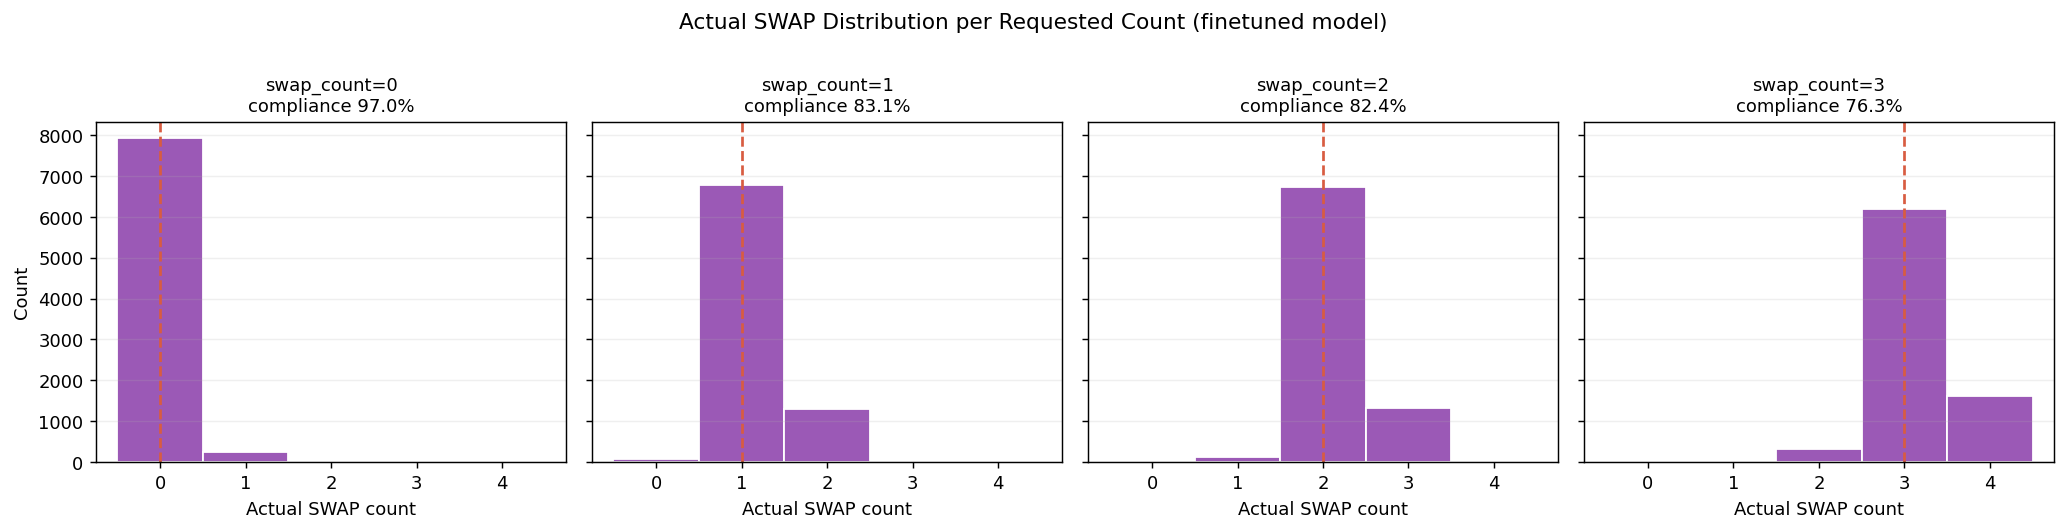

In [9]:
# Plot 2: Actual SWAP distribution per requested count — finetuned model
fig, axes = plt.subplots(1, len(SWAP_COUNTS), figsize=(4 * len(SWAP_COUNTS), 4), dpi=130, sharey=True)

max_swap_seen = max(
    results[("swap_finetuned", c)]["df"]["actual_swap"].dropna().max()
    for c in SWAP_COUNTS
    if len(results[("swap_finetuned", c)]["df"]["actual_swap"].dropna()) > 0
)
bins = np.arange(-0.5, max_swap_seen + 1.5, 1)

for ax, count in zip(axes, SWAP_COUNTS):
    df_c = results[("swap_finetuned", count)]["df"]
    valid_swaps = df_c[df_c["valid"]]["actual_swap"].dropna().astype(int)
    ax.hist(valid_swaps, bins=bins, color="#9b59b6", edgecolor="white")
    ax.axvline(count, color="#d85c41", linestyle="--", linewidth=1.5)
    compliance = (valid_swaps == count).mean()
    ax.set_title(f"swap_count={count}\ncompliance {compliance*100:.1f}%", fontsize=10)
    ax.set_xlabel("Actual SWAP count")
    if ax is axes[0]:
        ax.set_ylabel("Count")
    ax.grid(True, alpha=0.2, axis="y")

fig.suptitle("Actual SWAP Distribution per Requested Count (finetuned model)", fontsize=12, y=1.01)
plt.tight_layout()
save_figure(fig, ARTIFACT_DIR / "swap_distribution_per_count.png")
plt.show()

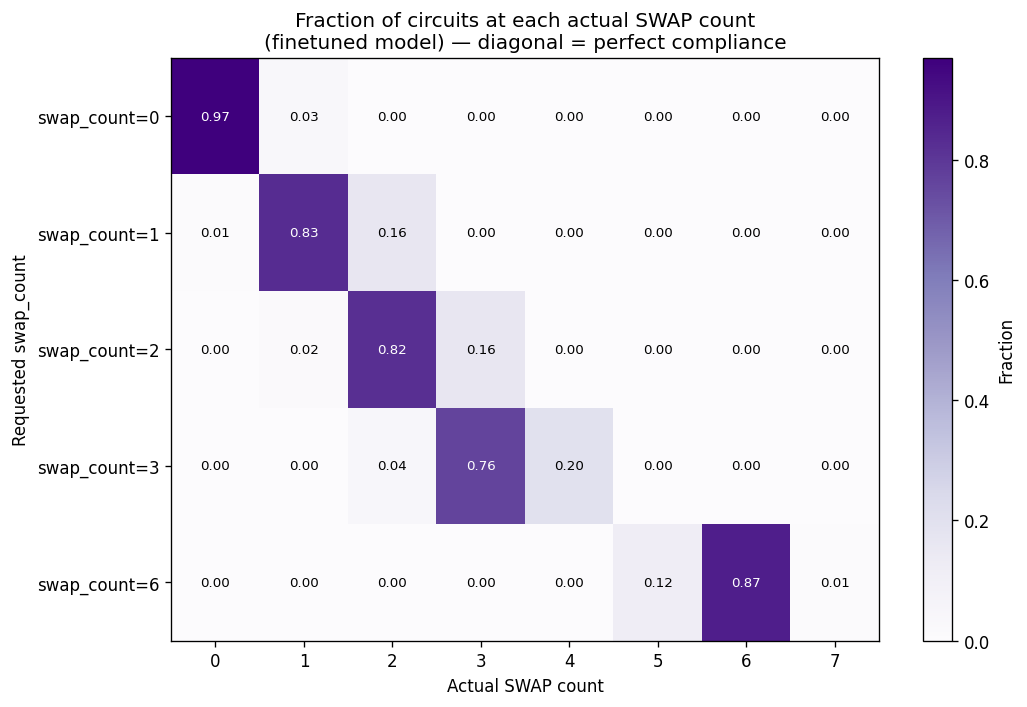

In [10]:
# Heatmap: requested count vs. actual SWAP count — finetuned model
all_counts = SWAP_COUNTS + [UNCONSTRAINED_COUNT]
max_actual = int(max(
    results[("swap_finetuned", c)]["df"]["actual_swap"].dropna().max()
    for c in all_counts
    if len(results[("swap_finetuned", c)]["df"]["actual_swap"].dropna()) > 0
))

heatmap = np.zeros((len(all_counts), max_actual + 1))
for i, count in enumerate(all_counts):
    valid_swaps = results[("swap_finetuned", count)]["df"]
    valid_swaps = valid_swaps[valid_swaps["valid"]]["actual_swap"].dropna().astype(int)
    for k in range(max_actual + 1):
        heatmap[i, k] = (valid_swaps == k).sum()
    row_sum = heatmap[i].sum()
    if row_sum > 0:
        heatmap[i] /= row_sum

fig, ax = plt.subplots(figsize=(max_actual + 2, len(all_counts) + 1), dpi=120)
im = ax.imshow(heatmap, aspect="auto", cmap="Purples", vmin=0)
ax.set_xticks(range(max_actual + 1))
ax.set_xticklabels(range(max_actual + 1))
ax.set_yticks(range(len(all_counts)))
ax.set_yticklabels([f"swap_count={c}" for c in all_counts])
ax.set_xlabel("Actual SWAP count")
ax.set_ylabel("Requested swap_count")
ax.set_title("Fraction of circuits at each actual SWAP count\n(finetuned model) — diagonal = perfect compliance")
plt.colorbar(im, ax=ax, label="Fraction")

for i in range(len(all_counts)):
    for j in range(max_actual + 1):
        ax.text(j, i, f"{heatmap[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if heatmap[i, j] > 0.5 else "black")

plt.tight_layout()
save_figure(fig, ARTIFACT_DIR / "requested_vs_actual_swap_heatmap.png")
plt.show()

## Infidelity of Wrong Circuits

For circuits that do NOT exactly implement the target unitary, how far off are they?
A small infidelity (close to 0) would suggest near-misses; a large infidelity suggests the model
is generating circuits that implement a completely different unitary.

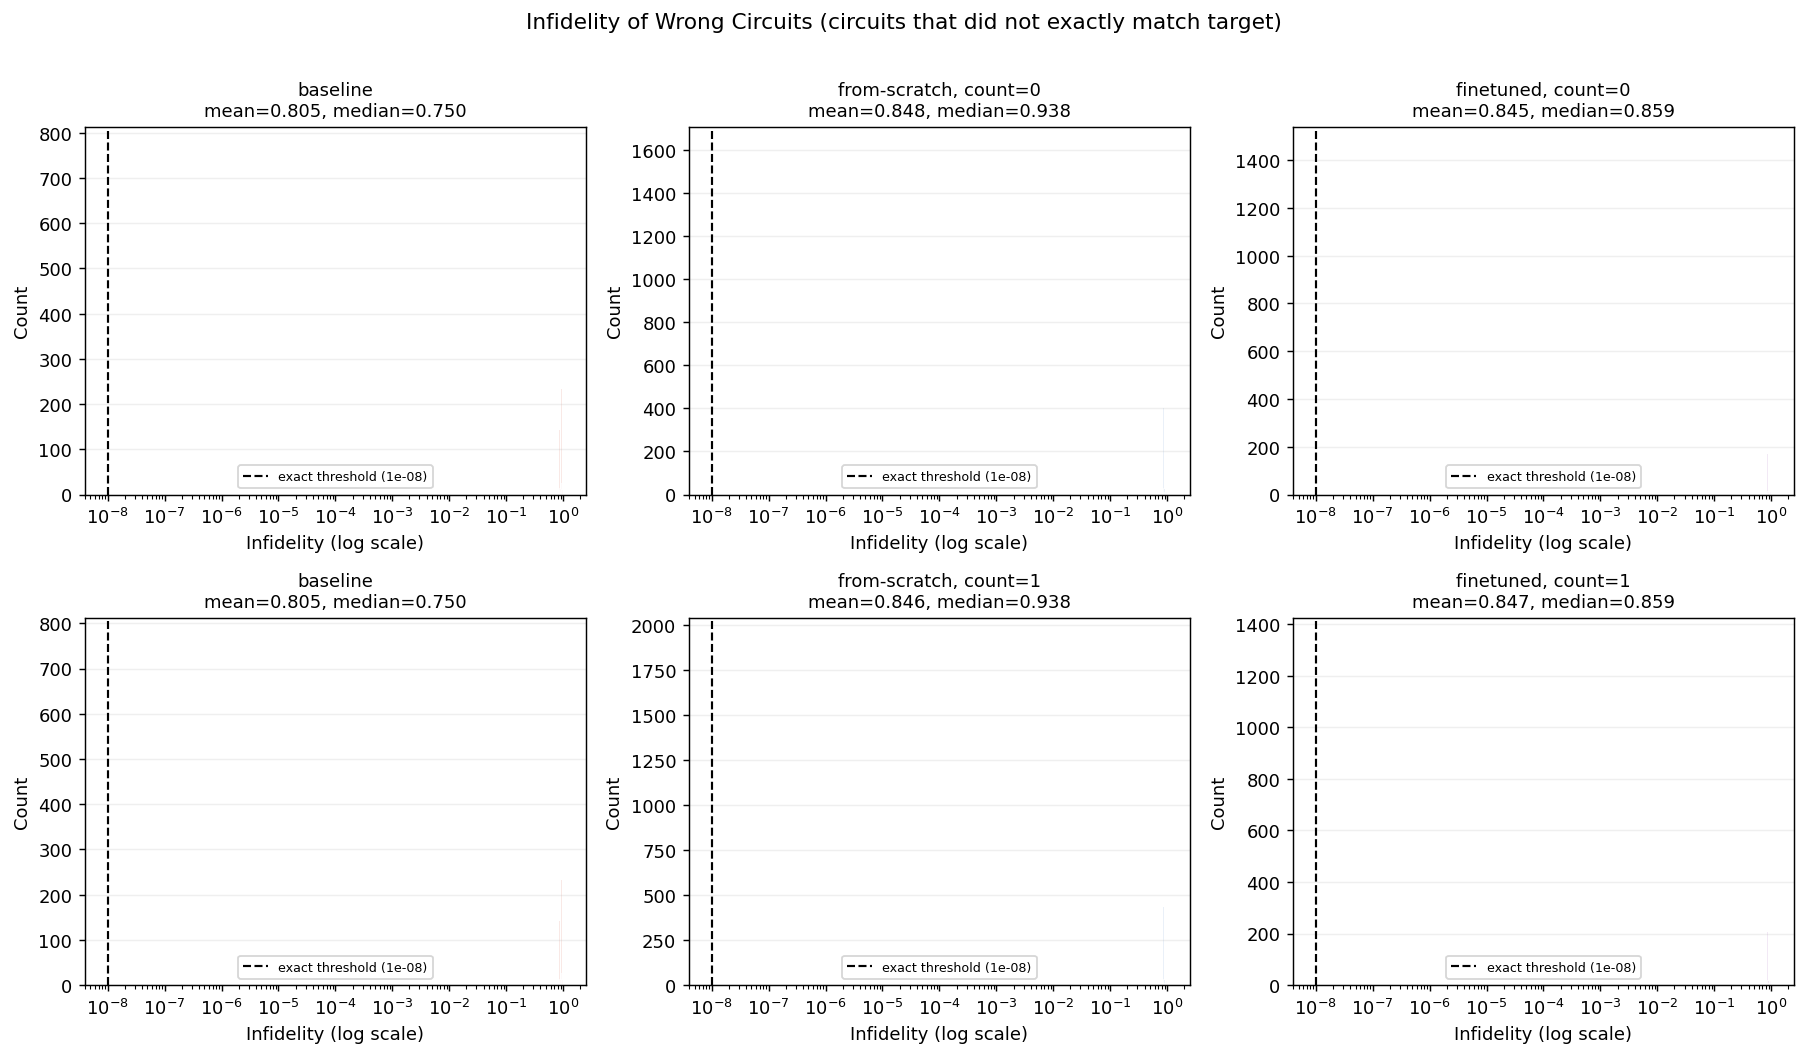


Mean / median infidelity of wrong circuits:


,label,n_wrong,mean_infidelity,median_infidelity,frac_infidelity_gt_01,frac_infidelity_gt_05
0,baseline,2026,0.8049,0.7500,1.0,0.9003
1,"from-scratch, count=0",5435,0.8480,0.9375,1.0,0.9303
2,"finetuned, count=0",3715,0.8452,0.8594,1.0,0.9585
3,"from-scratch, count=1",5915,0.8461,0.9375,1.0,0.9518
4,"finetuned, count=1",3473,0.8471,0.8594,1.0,0.9672


In [11]:

# Infidelity distribution for wrong circuits: all three models at count=0 and count=1
fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=130, sharey=False)

plot_cases_rows = [
    [
        ("baseline",        None, "#d85c41", "baseline"),
        ("swap_constrained", 0,   "#5f8fcb", "from-scratch, count=0"),
        ("swap_finetuned",   0,   "#9b59b6", "finetuned, count=0"),
    ],
    [
        ("baseline",        None, "#d85c41", "baseline"),
        ("swap_constrained", 1,   "#5f8fcb", "from-scratch, count=1"),
        ("swap_finetuned",   1,   "#9b59b6", "finetuned, count=1"),
    ],
]

for row_idx, plot_cases in enumerate(plot_cases_rows):
    all_wrong_infidelities = []
    for model, count, color, label in plot_cases:
        df = results[(model, count)]["df"]
        wrong = df[df["valid"] & ~df["exact"]]["infidelity"].dropna()
        all_wrong_infidelities.append(wrong.values)

    all_vals = np.concatenate(all_wrong_infidelities)
    if len(all_vals) > 0:
        log_bins = np.logspace(np.log10(max(all_vals.min(), 1e-9)), np.log10(all_vals.max() + 1e-9), 50)
    else:
        log_bins = np.logspace(-9, 0, 50)

    row_axes = axes[row_idx]
    for ax, (model, count, color, label), wrong_vals in zip(row_axes, plot_cases, all_wrong_infidelities):
        wrong = pd.Series(wrong_vals)
        ax.hist(wrong, bins=log_bins, color=color, edgecolor="white", alpha=0.85)
        ax.set_xscale("log")
        ax.axvline(EXACT_DISTANCE_TOL, color="black", linestyle="--", linewidth=1.2,
                   label=f"exact threshold ({EXACT_DISTANCE_TOL:.0e})")
        ax.set_xlabel("Infidelity (log scale)")
        ax.set_ylabel("Count")
        ax.set_title(f"{label}\nmean={wrong.mean():.3f}, median={wrong.median():.3f}", fontsize=10)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.2, axis="y")

fig.suptitle("Infidelity of Wrong Circuits (circuits that did not exactly match target)", fontsize=12, y=1.01)
plt.tight_layout()
save_figure(fig, ARTIFACT_DIR / "infidelity_wrong_circuits.png")
plt.show()

# Summary table
print("\nMean / median infidelity of wrong circuits:")
rows_inf = []
for model, count, _, label in plot_cases_rows[0] + plot_cases_rows[1][1:]:
    df = results[(model, count)]["df"]
    wrong = df[df["valid"] & ~df["exact"]]["infidelity"].dropna()
    rows_inf.append({
        "label": label,
        "n_wrong": len(wrong),
        "mean_infidelity": wrong.mean(),
        "median_infidelity": wrong.median(),
        "frac_infidelity_gt_01": (wrong > 0.1).mean(),
        "frac_infidelity_gt_05": (wrong > 0.5).mean(),
    })
display(pd.DataFrame(rows_inf).round(4))

In [12]:
# Save finetuned results (from-scratch + baseline are already saved in FROM_SCRATCH_ARTIFACT_DIR)
for (model, budget), payload in results.items():
    if model != "swap_finetuned":
        continue
    label = f"{model}_budget{budget}"
    save_dataframe(payload["df"], ARTIFACT_DIR / f"{label}_per_circuit.csv", index=False)

summaries = [v["summary"] for v in results.values()]
save_dataframe(pd.DataFrame(summaries), ARTIFACT_DIR / "swap_budget_summary.csv", index=False)

save_json(
    {
        "eval_dataset_path": EVAL_DATASET_PATH,
        "finetuned_model_dir": FINETUNED_MODEL_DIR,
        "baseline_model_dir": BASELINE_MODEL_DIR,
        "swap_model_dir": SWAP_MODEL_DIR,
        "from_scratch_artifact_dir": str(FROM_SCRATCH_ARTIFACT_DIR),
        "swap_counts": SWAP_COUNTS,
        "unconstrained_count": UNCONSTRAINED_COUNT,
        "num_eval_unitaries": NUM_EVAL_UNITARIES,
        "samples_per_unitary": SAMPLES_PER_UNITARY,
        "guidance_scale": GUIDANCE_SCALE,
        "exact_distance_tol": EXACT_DISTANCE_TOL,
        "seed": SEED,
        "summaries": summaries,
    },
    ARTIFACT_DIR / "run_config.json",
)
print(f"Saved finetuned evaluation artifacts to {ARTIFACT_DIR}")

Saved finetuned evaluation artifacts to /home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/unitary-swap-finetuned/swap_count_evaluation


## Interpretation Guide

**The heatmap is the key diagnostic.** A well-trained model shows mass concentrated on the diagonal: row `swap_count=0` mostly at column 0, row `swap_count=2` mostly at column 2, etc. Blurring across adjacent columns is expected (CLIP number separation is ~0.30 L2 for integers 1–3); complete lack of diagonal structure means the conditioning isn't working.

**Exact-count compliance per requested value:**
- `swap_count=0`: cleanest signal (largest CLIP step from 0→1 at L2=0.52). Compliance > 60% is a good result.
- `swap_count=1/2/3`: CLIP separation is weaker (~0.30). Expect softer compliance; mean_actual_swap tracking the direction matters more than hitting exactly.

**Accuracy vs. requested count:**
- Mild accuracy drop at `swap_count=0` is expected — some unitaries genuinely need SWAPs for correct compilation.
- At `swap_count=2+`, accuracy should be within a few percent of the baseline. A large drop suggests the added token is hurting general compilation quality.

**Unconstrained reference (`swap_count=6`) vs. baseline:**
- These should have comparable `exact_found_rate`. A large gap means the extra token in the prompt shifts the distribution even when the count is loose — a sign the model needs more training.

**If results are disappointing:**
- Compliance weak across all counts → consider a dedicated numerical embedding (replace CLIP number tokens with a learned 1D lookup projected into the 512-dim condition space)
- Compliance OK for 0 but not 1/2/3 → CLIP number separation is the bottleneck; categorical labels or numerical embedding would help
- Accuracy drops significantly even at high counts → balance the dataset by swap_count bucket and/or train longer